In [28]:
import pandas as pd
import networkx as nx
import re
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## How many Proteins Get Lost From GE-radical-scoring to KG-mapping

In [13]:
adni_ecdf_scoring_path = "../AD/data/ADNI/sample_scoring/sample_scoring_ecdf.csv"
adni_ecdf_graph_summary_path = "../datasets/Patient_KGs/Summary_adni_ADKG_ecdf.csv"

def radical_to_kgmap(scoring_path:str, 
                    graph_summary_path:str, 
                    kg:str='AD_KG',
                    dataset:str='adni',
                    scoring_method:str='ecdf'):
    
    df_scoring = pd.read_csv(scoring_path, index_col=0)
    df_graph_summary = pd.read_csv(graph_summary_path, index_col=0)

    connections_count = df_graph_summary.sum(axis=1)


    difference = non_zeros - connections_count
    ratio = connections_count/non_zeros
    df_analysis = pd.DataFrame(
        {'Significantly_Expressed_Proteins': non_zeros,
        'Connected_to_KG_Proteins': connections_count,
        'Difference': difference,
        'Ratio': ratio},
        index = df_graph_summary.index)
    
    df_analysis['Connected_KG'] = kg
    df_analysis['Dataset'] = dataset
    df_analysis['Scoring_Method'] = scoring_method
    
    return df_analysis

# To AD-KG

In [14]:
# adni ecdf -> AD-KG
df_adni_ecdf_adkg = radical_to_kgmap(adni_ecdf_scoring_path, adni_ecdf_graph_summary_path)
df_adni_ecdf_adkg

,Significantly_Expressed_Proteins,Connected_to_KG_Proteins,Difference,Ratio,Connected_KG,Dataset,Scoring_Method
116_S_1249,2080,68,2012,0.032692,AD_KG,adni,ecdf
037_S_4410,5083,217,4866,0.042691,AD_KG,adni,ecdf
006_S_4153,1096,45,1051,0.041058,AD_KG,adni,ecdf
116_S_1232,1137,33,1104,0.029024,AD_KG,adni,ecdf
128_S_0205,3795,148,3647,0.038999,AD_KG,adni,ecdf
...,...,...,...,...,...,...,...
014_S_4668,2088,64,2024,0.030651,AD_KG,adni,ecdf
130_S_0289,2431,91,2340,0.037433,AD_KG,adni,ecdf
009_S_2381,1649,65,1584,0.039418,AD_KG,adni,ecdf
041_S_4014,4038,153,3885,0.037890,AD_KG,adni,ecdf


In [25]:
scoring_types = ['ecdf', 'std', 'all']
datasets = ['adni', 'geo']
kgs = ['Patient_KGs', 'Prime_KGs', 'PPI_KGs']

dfs = {}
for dataset in datasets:
    # to store dfs
    dfs[dataset]=[]

    for kg in kgs:
        if dataset == 'adni':
            base_scoring_path = "../AD/data/ADNI/sample_scoring"
        else:
            base_scoring_path = "../AD/data/GEO/GSE33000_ad_hd/sample_scoring"
        
        for scoring in scoring_types:

            scoring_path = os.path.join(base_scoring_path, f'sample_scoring_{scoring}.csv')
            graph_summary_path = f"../datasets/{kg}/Summary_{dataset}_ADKG_{scoring}.csv"

            if not os.path.exists(scoring_path) or not os.path.exists(graph_summary_path):
                print(f"Path {scoring_path} or {graph_summary_path} Not Exists!")
                continue

            df = radical_to_kgmap(scoring_path = scoring_path,
                                  graph_summary_path = graph_summary_path,
                                  kg=kg,
                                  dataset=dataset,
                                  scoring_method=scoring)
            dfs[dataset].append(df)

Path ../AD/data/ADNI/sample_scoring/sample_scoring_std.csv or ../datasets/Patient_KGs/Summary_adni_ADKG_std.csv Not Exists!
Path ../AD/data/ADNI/sample_scoring/sample_scoring_all.csv or ../datasets/Patient_KGs/Summary_adni_ADKG_all.csv Not Exists!
Path ../AD/data/GEO/GSE33000_ad_hd/sample_scoring/sample_scoring_std.csv or ../datasets/Patient_KGs/Summary_geo_ADKG_std.csv Not Exists!
Path ../AD/data/GEO/GSE33000_ad_hd/sample_scoring/sample_scoring_all.csv or ../datasets/Patient_KGs/Summary_geo_ADKG_all.csv Not Exists!


In [26]:
len(dfs['adni'])

7

In [27]:
dfs['adni']

[            Significantly_Expressed_Proteins  Connected_to_KG_Proteins  \
 116_S_1249                              2080                        68   
 037_S_4410                              5083                       217   
 006_S_4153                              1096                        45   
 116_S_1232                              1137                        33   
 128_S_0205                              3795                       148   
 ...                                      ...                       ...   
 014_S_4668                              2088                        64   
 130_S_0289                              2431                        91   
 009_S_2381                              1649                        65   
 041_S_4014                              4038                       153   
 007_S_0101                              1769                        82   
 
             Difference     Ratio Connected_KG Dataset Scoring_Method  
 116_S_1249        2012  0

## Visualize

In [33]:
def plot_df(dfs:dict, dataset:str='adni'):
    # 1. Concatenate the DataFrames 
    # pd.concat merges list of dfs vertically.
    # Reset the index to keep  patient idx as a usable column.
    df_list = dfs['adni']
    master_df = pd.concat(df_list).reset_index().rename(columns={'index': 'Patient_ID'})

    print("Master DataFrame Shape:", master_df.shape)

    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.dpi'] = 150


    # --- VISUALIZATION 1: Boxplot with Min, Max, Mean annotations ---
    g1 = sns.catplot(
        data=master_df, 
        x="Scoring_Method", 
        y="Connected_to_KG_Proteins", 
        col="Connected_KG", 
        kind="box",
        palette="Set2",
        height=6, 
        aspect=0.9
    )
    g1.set_titles("{col_name}")
    g1.set_axis_labels("Scoring Method", "Connected to KG Proteins")
    plt.subplots_adjust(top=0.82)
    g1.fig.suptitle("Distribution of Connected KG Proteins\n(With Min, Mean, Max Annotations)", fontsize=14, weight='bold')

    # Loop through each subplot/column to inject the text labels
    for kg_name, ax in g1.axes_dict.items():
        # Filter master data to match only this specific subplot's Knowledge Graph
        sub_df = master_df[master_df['Connected_KG'] == kg_name]
        
        # Get the x-axis categories in order
        categories = [text.get_text() for text in ax.get_xticklabels()]
        
        # Calculate stats for each category (Scoring Method)
        for i, cat in enumerate(categories):
            cat_data = sub_df[sub_df['Scoring_Method'] == cat]['Connected_to_KG_Proteins']
            
            if len(cat_data) > 0:
                v_min = cat_data.min()
                v_max = cat_data.max()
                v_mean = cat_data.mean()
                
                # Place text labels next to the boxes. 
                # i represents the X-coordinate. We offset slightly to the right (i + 0.22)
                # We use an edge color/bbox to ensure it remains readable over gridlines
                text_str = f"Max: {v_max:.0f}\nMean: {v_mean:.1f}\nMin: {v_min:.0f}"
                ax.text(i + 0.24, v_mean, text_str, color='black', weight='semibold',
                        fontsize=8, ha='left', va='center',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))


    # --- VISUALIZATION 2: Violin plot with Min, Max, Mean annotations ---
    g2 = sns.catplot(
        data=master_df, 
        x="Scoring_Method", 
        y="Ratio", 
        col="Connected_KG", 
        kind="violin",
        palette="muted",
        inner="quart",
        height=6, 
        aspect=0.9
    )
    g2.set_titles("{col_name}")
    g2.set_axis_labels("Scoring Method", "Ratio Value")
    plt.subplots_adjust(top=0.82)
    g2.fig.suptitle("Ratio Analysis across Configurations\n(With Min, Mean, Max Annotations)", fontsize=14, weight='bold')

    # Repeat the text injection process for the second grid
    for kg_name, ax in g2.axes_dict.items():
        sub_df = master_df[master_df['Connected_KG'] == kg_name]
        categories = [text.get_text() for text in ax.get_xticklabels()]
        
        for i, cat in enumerate(categories):
            cat_data = sub_df[sub_df['Scoring_Method'] == cat]['Ratio']
            
            if len(cat_data) > 0:
                v_min = cat_data.min()
                v_max = cat_data.max()
                v_mean = cat_data.mean()
                
                # Format decimals to 3 decimal places for ratios since they are small float numbers
                text_str = f"Max: {v_max:.3f}\nMean: {v_mean:.3f}\nMin: {v_min:.3f}"
                ax.text(i + 0.26, v_mean, text_str, color='black', weight='semibold',
                        fontsize=8, ha='left', va='center',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.show()

    return master_df

In [32]:
for df in dfs['adni']:
    print(df)

            Significantly_Expressed_Proteins  Connected_to_KG_Proteins  \
116_S_1249                              2080                        68   
037_S_4410                              5083                       217   
006_S_4153                              1096                        45   
116_S_1232                              1137                        33   
128_S_0205                              3795                       148   
...                                      ...                       ...   
014_S_4668                              2088                        64   
130_S_0289                              2431                        91   
009_S_2381                              1649                        65   
041_S_4014                              4038                       153   
007_S_0101                              1769                        82   

            Difference     Ratio Connected_KG Dataset Scoring_Method  
116_S_1249        2012  0.032692  Patien

Master DataFrame Shape: (3185, 8)


/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_77542/1103258891.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1 = sns.catplot(
/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_77542/1103258891.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 = sns.catplot(


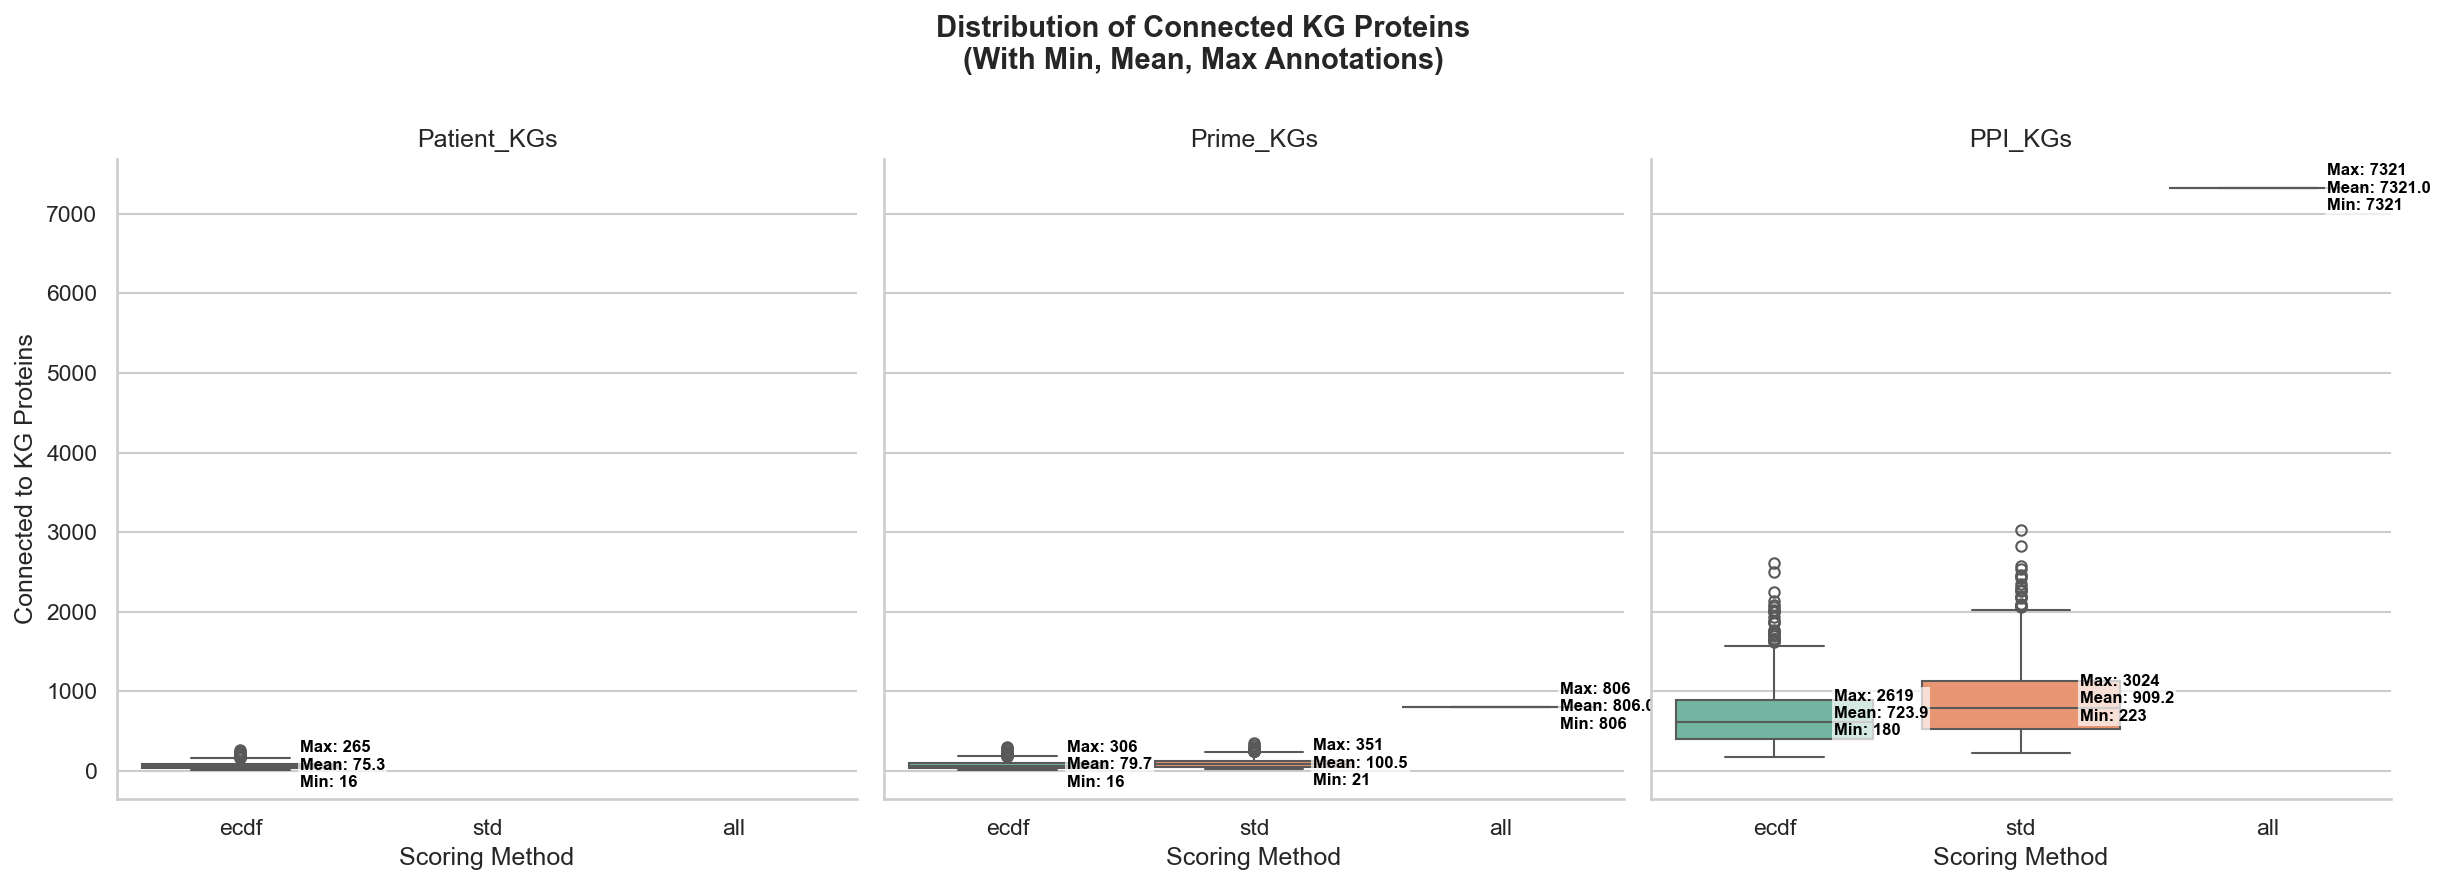

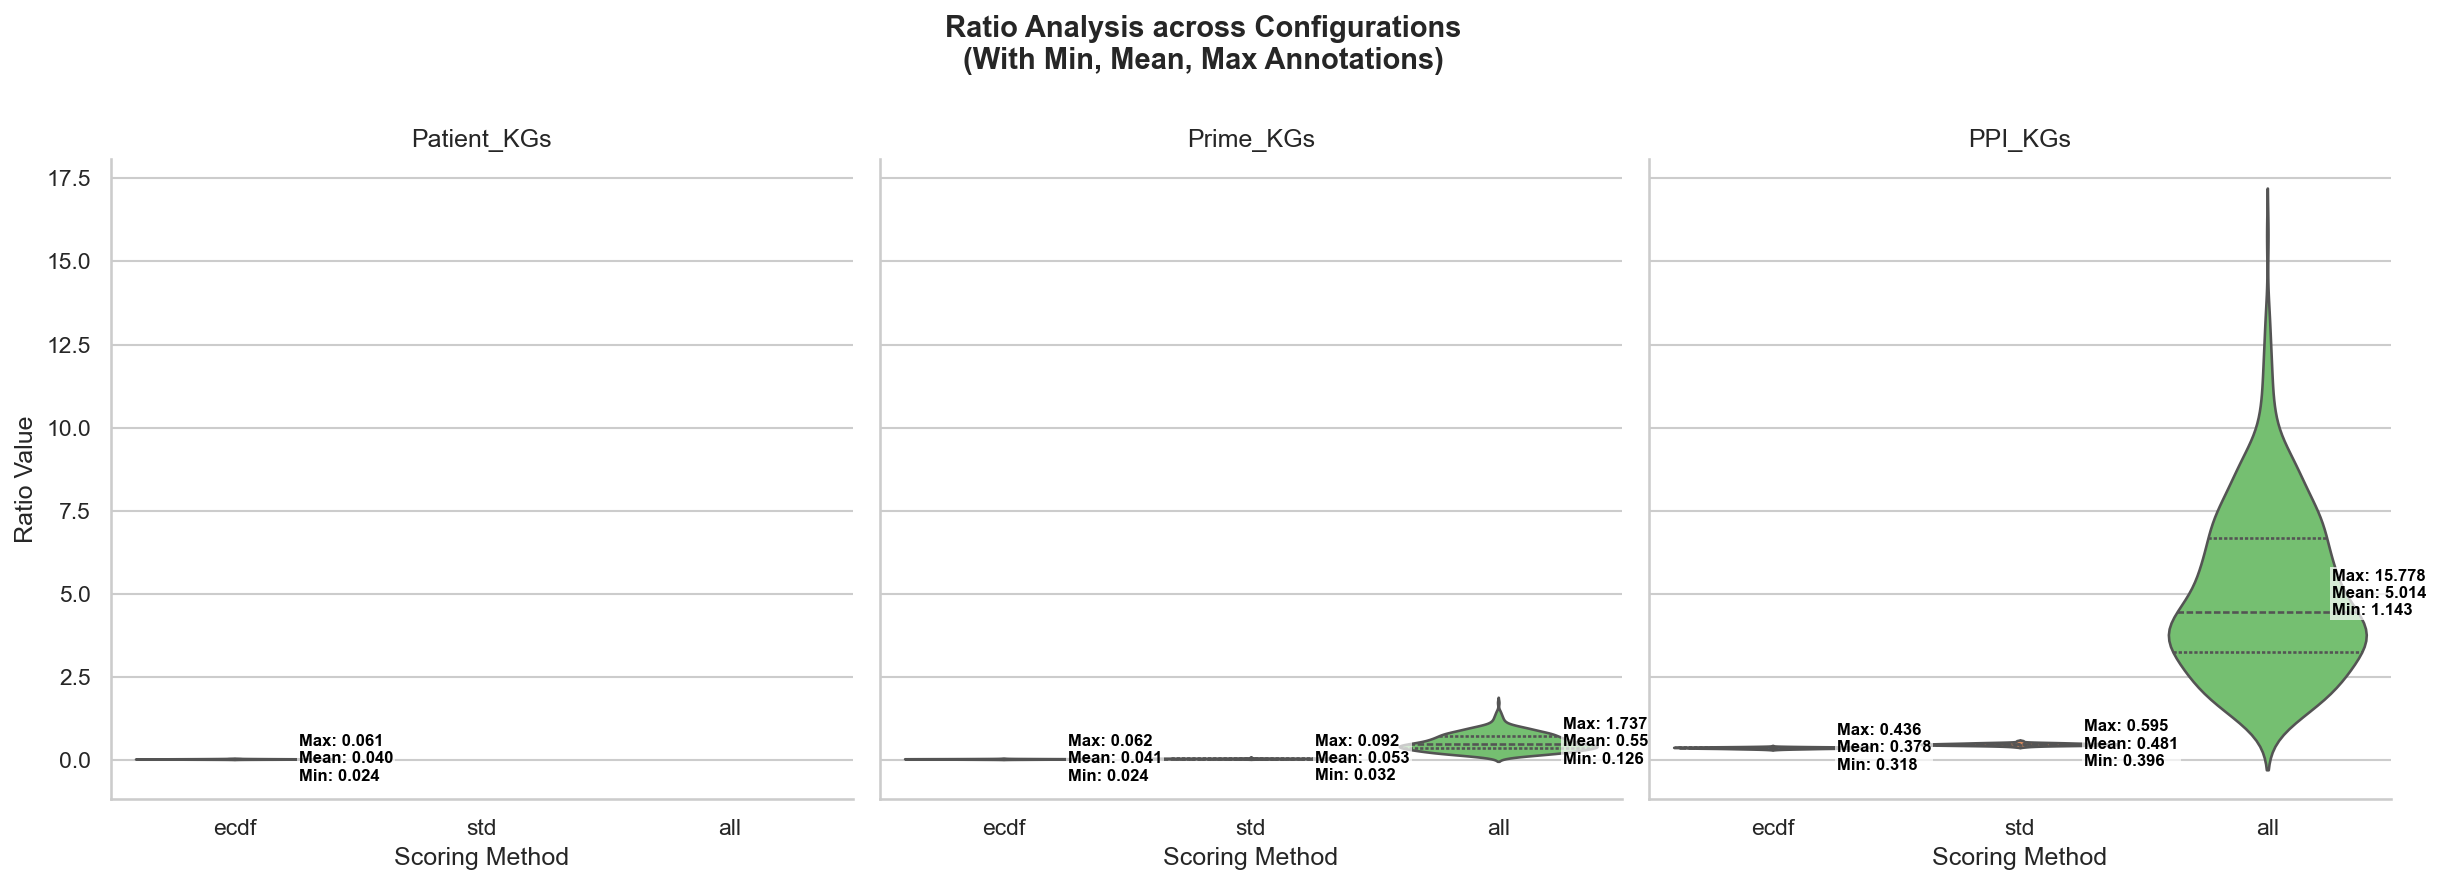

,Patient_ID,Significantly_Expressed_Proteins,Connected_to_KG_Proteins,Difference,Ratio,Connected_KG,Dataset,Scoring_Method
0,116_S_1249,2080,68,2012,0.032692,Patient_KGs,adni,ecdf
1,037_S_4410,5083,217,4866,0.042691,Patient_KGs,adni,ecdf
2,006_S_4153,1096,45,1051,0.041058,Patient_KGs,adni,ecdf
3,116_S_1232,1137,33,1104,0.029024,Patient_KGs,adni,ecdf
4,128_S_0205,3795,148,3647,0.038999,Patient_KGs,adni,ecdf
...,...,...,...,...,...,...,...,...
3180,014_S_4668,2088,7321,-5233,3.506226,PPI_KGs,adni,all
3181,130_S_0289,2431,7321,-4890,3.011518,PPI_KGs,adni,all
3182,009_S_2381,1649,7321,-5672,4.439660,PPI_KGs,adni,all
3183,041_S_4014,4038,7321,-3283,1.813026,PPI_KGs,adni,all


In [34]:
plot_df(dfs, 'adni')

Master DataFrame Shape: (3185, 8)


/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_77542/1103258891.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1 = sns.catplot(
/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_77542/1103258891.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 = sns.catplot(


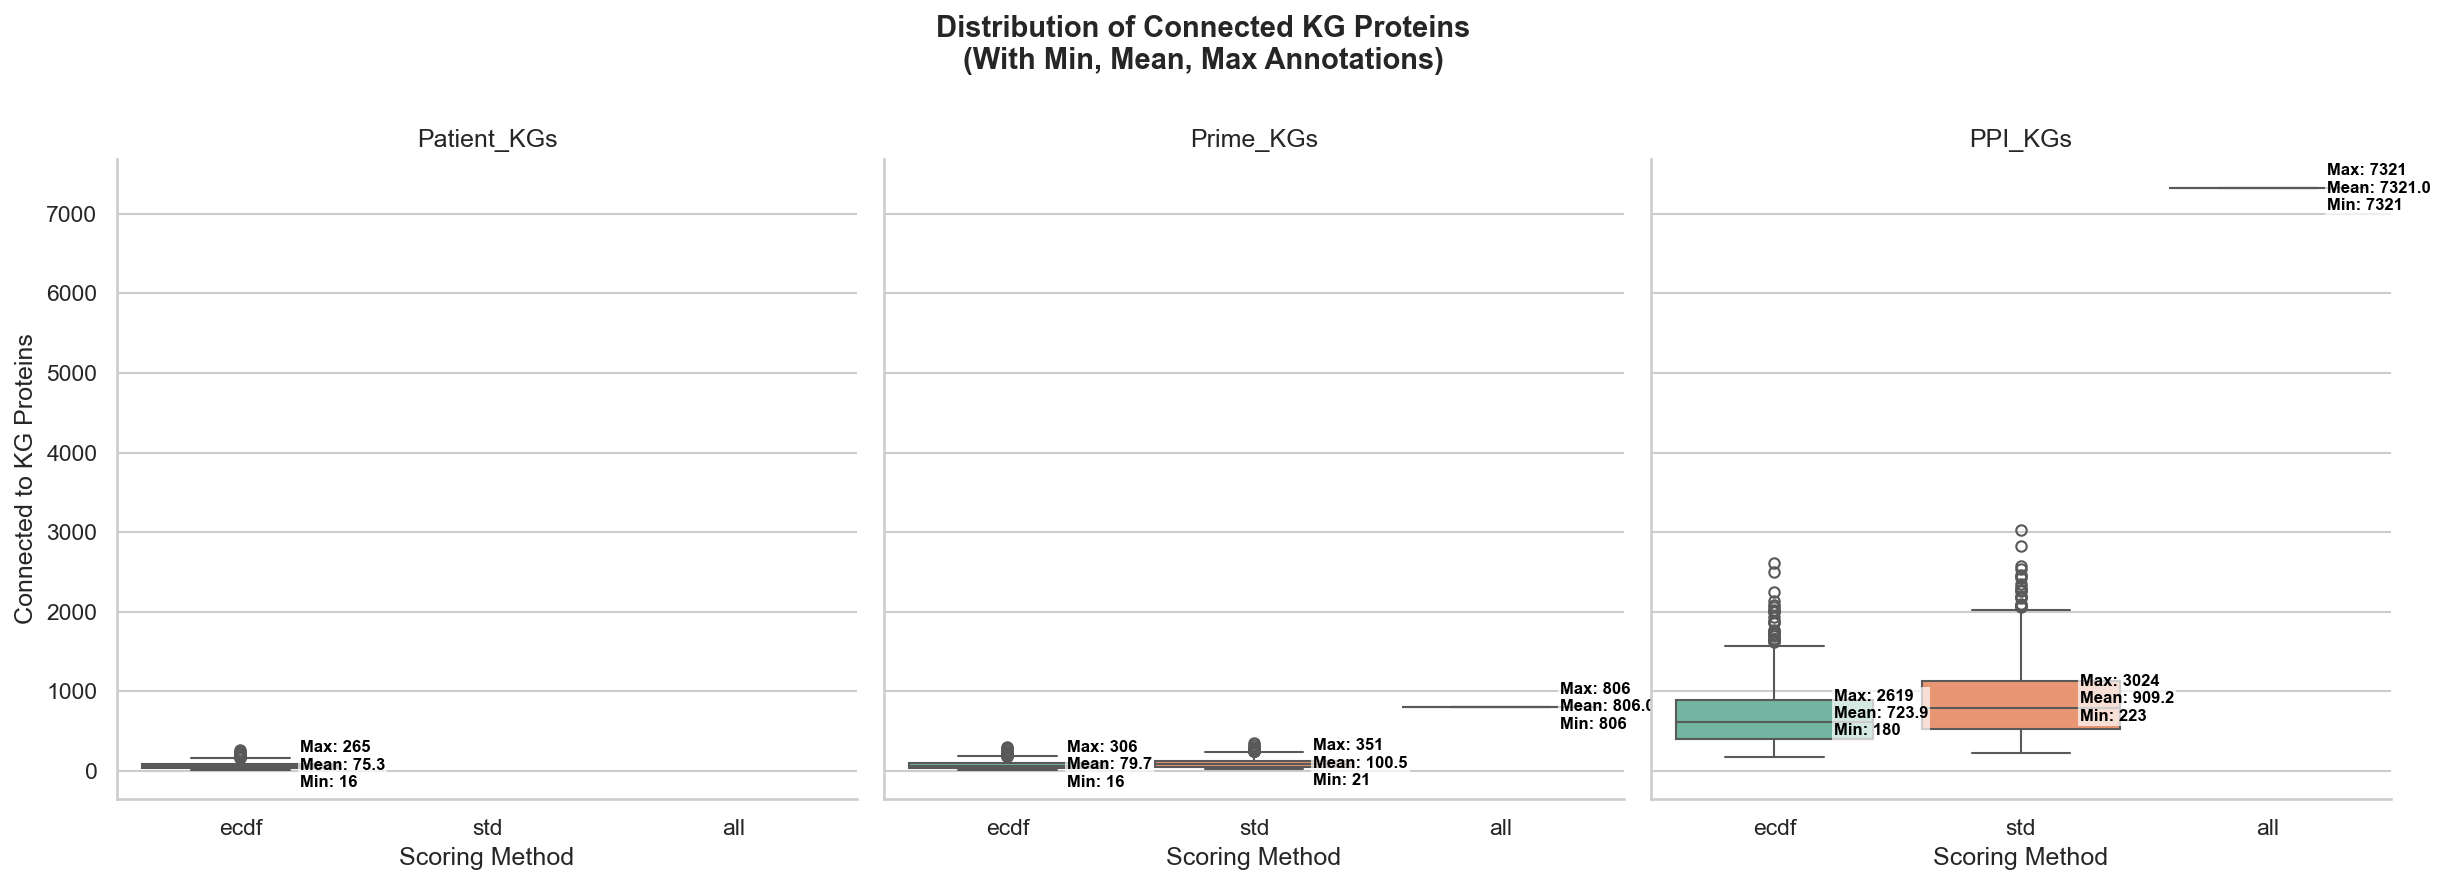

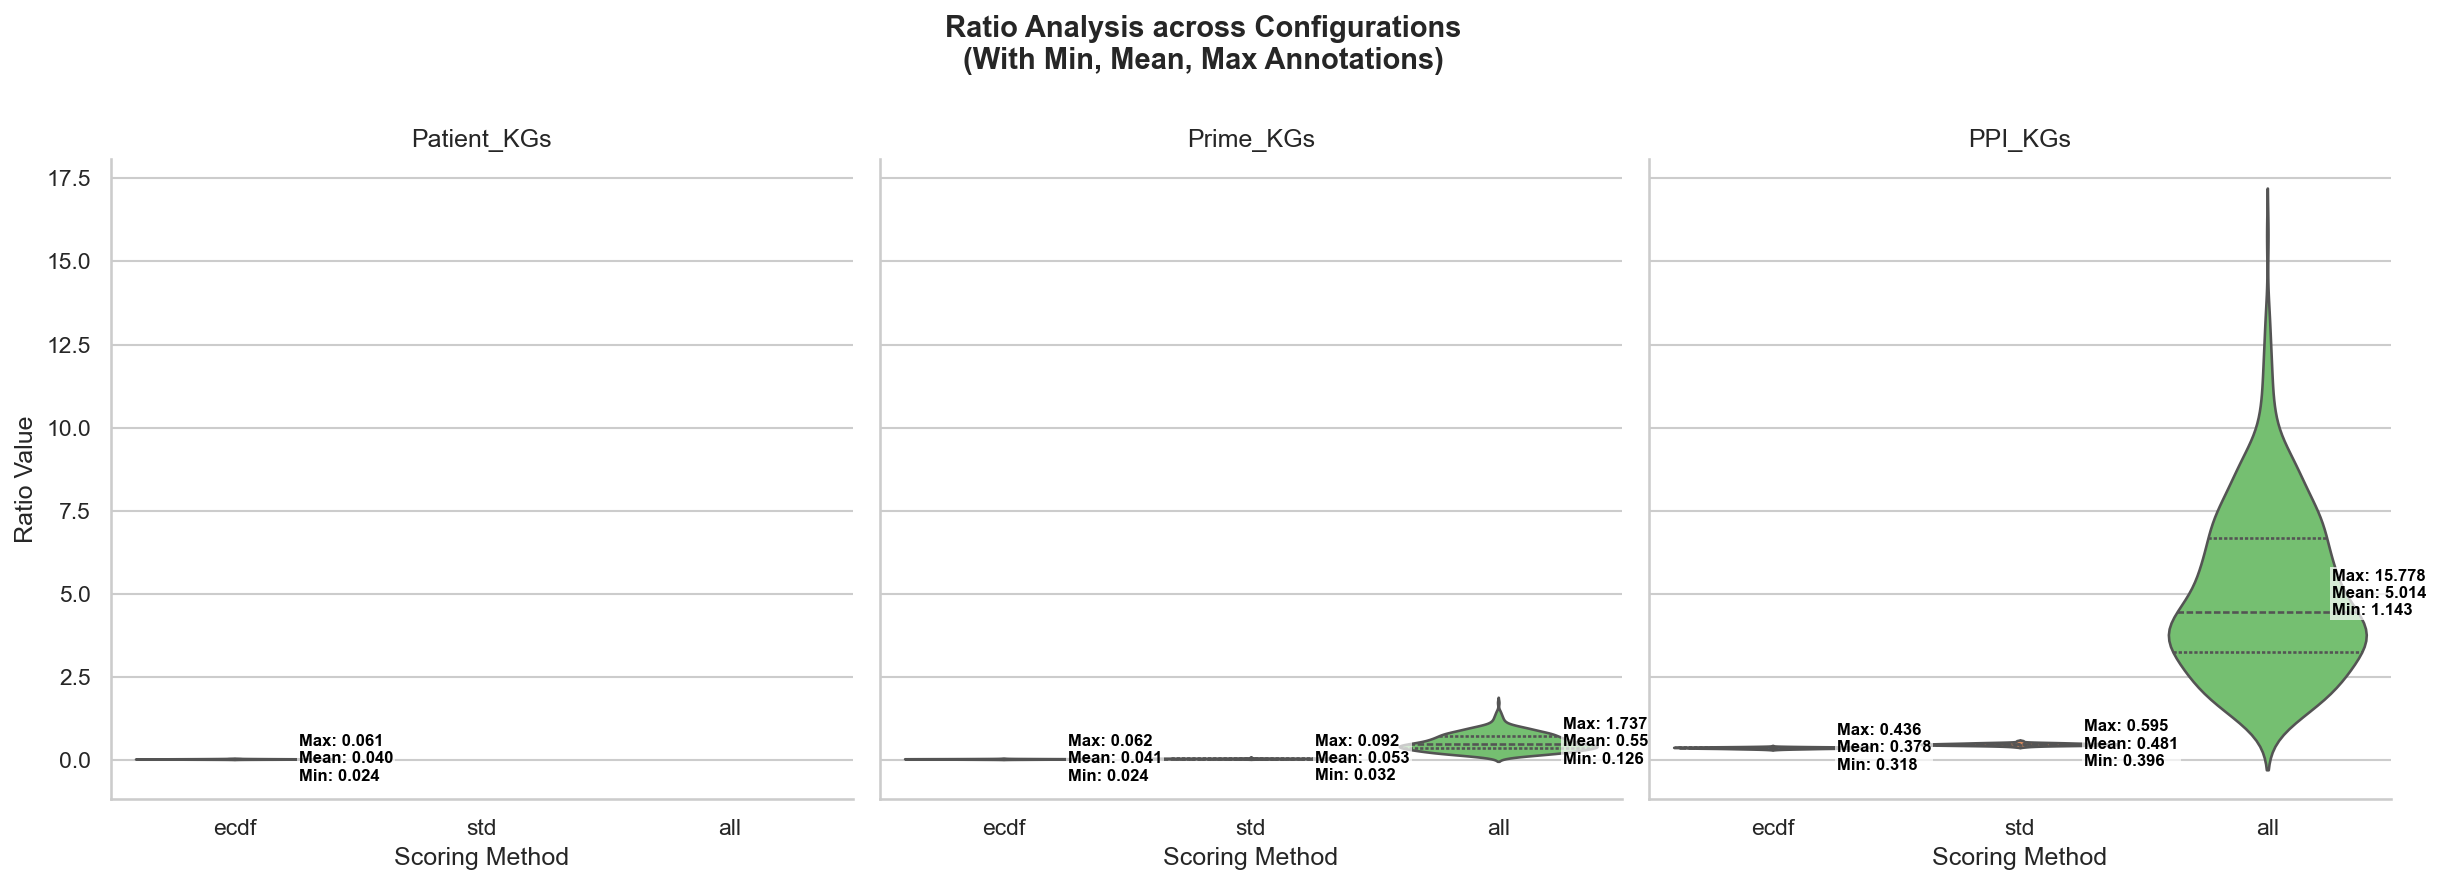

,Patient_ID,Significantly_Expressed_Proteins,Connected_to_KG_Proteins,Difference,Ratio,Connected_KG,Dataset,Scoring_Method
0,116_S_1249,2080,68,2012,0.032692,Patient_KGs,adni,ecdf
1,037_S_4410,5083,217,4866,0.042691,Patient_KGs,adni,ecdf
2,006_S_4153,1096,45,1051,0.041058,Patient_KGs,adni,ecdf
3,116_S_1232,1137,33,1104,0.029024,Patient_KGs,adni,ecdf
4,128_S_0205,3795,148,3647,0.038999,Patient_KGs,adni,ecdf
...,...,...,...,...,...,...,...,...
3180,014_S_4668,2088,7321,-5233,3.506226,PPI_KGs,adni,all
3181,130_S_0289,2431,7321,-4890,3.011518,PPI_KGs,adni,all
3182,009_S_2381,1649,7321,-5672,4.439660,PPI_KGs,adni,all
3183,041_S_4014,4038,7321,-3283,1.813026,PPI_KGs,adni,all


In [35]:
plot_df(dfs, 'geo')